## Name: Shamir Maharjan
## Student ID: 2417731
## Workshop 2

# Building a Softmax Regression for MNIST Digit Classification:

## Softmax Function:

In [3]:
import numpy as np
def softmax(z):
    """
    Compute the softmax probabilities for a given input matrix.
    Parameters:
    z (numpy.ndarray): Logits (raw scores) of shape (m, n), where

    - m is the number of samples.
    - n is the number of classes.

    Returns:
    numpy.ndarray: Softmax probability matrix of shape (m, n), where
    each row sums to 1 and represents the probability
    distribution over classes.

    Notes:
    - The input to softmax is typically computed as: z = XW + b.
    - Uses numerical stabilization by subtracting the max value per row.
    """

#For numerical stability, subtract the max of each row
    # This prevents overflow when computing exp(large numbers)
    z_stable = z - np.max(z, axis=1, keepdims=True)

    exp_z = np.exp(z_stable) # makes everything positive

#Normalize by dividing each row by its sum
    # axis=1 means "sum across columns" → gives sum per sample
    sum_exp_z = np.sum(exp_z, axis=1, keepdims=True)
    probabilites = exp_z/sum_exp_z  #gives the probability of each turns them into percentage

    return probabilites

## Softmax Test Function.

In [5]:
# This test case checks that each row in the resulting softmax probabilities sums to 1, which is the fundamental property of softmax.
# Example test case
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)
# Verify if the sum of probabilities for each row is 1 using assert
row_sums = np.sum(softmax_output, axis=1)
print(row_sums)
# Assert that the sum of each row is 1
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"
print("Softmax function passed the test case!")

[1. 1.]
Softmax function passed the test case!


## Prediction Function:

In [13]:
def predict_softmax(X, W, b):
    """
    Predict the class labels for a set of samples using the trained softmax model.
    Parameters:
    X (numpy.ndarray): Feature matrix of shape (n, d), where n is the number of samples and d is the
    number of features.
    W (numpy.ndarray): Weight matrix of shape (d, c), where c is the number of classes.
    b (numpy.ndarray): Bias vector of shape (c,).
    Returns:
    numpy.ndarray: Predicted class labels of shape (n,), where each value is the index of the
    predicted class.
    """

    #Compute raw scores (logits) for each class
    # Formula: Z = X * W + b
    Z = X @ W + b;  # Shape: (n, c)

    #Convert scores to probabilities using softmax
    probabilities = softmax(Z)

    #Pick the class with highest probability for each sample
    predicted_classes = np.argmax(probabilities, axis=1)
    return predicted_classes

## Prediction Test Case.

In [15]:
# The test function ensures that the predicted class labels have the same number of elements as the
# input samples, verifying that the model produces a valid output shape.
# Define test case
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]]) # Feature matrix (3 samples, 2 features)
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]]) # Weights (2 features, 3 classes)
b_test = np.array([0.1, 0.2, 0.3]) # Bias (3 classes)
# Expected Output:
# The function should return an array with class labels (0, 1, or 2)
y_pred_test = predict_softmax(X_test, W_test, b_test)
# Validate output shape
assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"
# Print the predicted labels
print("Predicted class labels:", y_pred_test)

Predicted class labels: [1 1 0]


## Implementation of Loss Function:

In [23]:
def loss_softmax(y_pred, y):
    """
    Compute the cross-entropy loss for a single sample.
    Parameters:
    y_pred (numpy.ndarray): Predicted probabilities of shape (c,) for a single sample,

    where c is the number of classes.

    y (numpy.ndarray): True labels (one-hot encoded) of shape (c,), where c is the number of classes.
    Returns:
    float: Cross-entropy loss for the given sample.
    """

    epsilon = 1e-15

    y_pred_safe = np.clip(y_pred, epsilon, 1-epsilon)

    loss_per_sample = -np.sum(y * np.log(y_pred_safe), axis=1)

    loss = np.mean(loss_per_sample)
    return float(loss)

## Test case for Loss Function:

In [26]:
import numpy as np

def loss_softmax(y_pred, y):
    epsilon = 1e-15
    y_pred_safe = np.clip(y_pred, epsilon, 1 - epsilon)
    loss_per_sample = -np.sum(y * np.log(y_pred_safe), axis=1)
    loss = np.mean(loss_per_sample)
    return float(loss)

# True labels (3 samples, 3 classes)
y_true_correct = np.array([[1, 0, 0], 
                           [0, 1, 0], 
                           [0, 0, 1]])

# Correct predictions (high confidence in right class)
y_pred_correct = np.array([[0.9, 0.05, 0.05],
                           [0.1, 0.85, 0.05],
                           [0.05, 0.1, 0.85]])

# Incorrect predictions (high confidence in WRONG class)
y_pred_incorrect = np.array([[0.05, 0.05, 0.9],
                             [0.1, 0.05, 0.85],
                             [0.85, 0.1, 0.05]])

# Compute loss for both cases
loss_correct = loss_softmax(y_pred_correct, y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)

# Validate
assert loss_correct < loss_incorrect, f"Test failed: Expected loss_correct < loss_incorrect, but got {loss_correct:.4f} >= {loss_incorrect:.4f}"

# Print results
print(f"Cross-Entropy Loss (Correct Predictions): {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")

Cross-Entropy Loss (Correct Predictions): 0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957


## Implementation of Cost Function:

In [27]:
def cost_softmax(X, y, W, b):
    """
    Compute the average softmax regression cost (cross-entropy loss) over all samples.
    Parameters:
    X (numpy.ndarray): Feature matrix of shape (n, d), where n is the number of samples and d is the
    number of features.
    y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c), where n is the number of
    samples and c is the number of classes.
    W (numpy.ndarray): Weight matrix of shape (d, c).
    b (numpy.ndarray): Bias vector of shape (c,).
    Returns:
    float: Average softmax cost (cross-entropy loss) over all samples.
    """

    #Get number of samples
    n = X.shape[0]

    z = X @ W + b

    probabilities = softmax(z)

    epsilon = 1e-15

    probabilities_safe = np.clip(probabilities, epsilon, 1-epsilon)

    total_loss = -np.sum(y * np.log(probabilities_safe), axis=1)

    # Return average loss
    return float(np.mean(total_loss))

## Test case for Cost Function.

In [29]:
# The test case assures that the cost for the incorrect prediction should be higher than for the
# correct prediction, confirming that the cost function behaves as expected.
import numpy as np
# Example 1: Correct Prediction (Closer predictions)
X_correct = np.array([[1.0, 0.0], [0.0, 1.0]]) # Feature matrix for correct predictions
y_correct = np.array([[1, 0], [0, 1]]) # True labels (one-hot encoded, matching predictions)
W_correct = np.array([[5.0, -2.0], [-3.0, 5.0]]) # Weights for correct prediction
b_correct = np.array([0.1, 0.1]) # Bias for correct prediction
# Example 2: Incorrect Prediction (Far off predictions)
X_incorrect = np.array([[0.1, 0.9], [0.8, 0.2]]) # Feature matrix for incorrect predictions
y_incorrect = np.array([[1, 0], [0, 1]]) # True labels (one-hot encoded, incorrect predictions)
W_incorrect = np.array([[0.1, 2.0], [1.5, 0.3]]) # Weights for incorrect prediction
b_incorrect = np.array([0.5, 0.6]) # Bias for incorrect prediction
# Compute cost for correct predictions
cost_correct = cost_softmax(X_correct, y_correct, W_correct, b_correct)
# Compute cost for incorrect predictions
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)
# Check if the cost for incorrect predictions is greater than for correct predictions
assert cost_incorrect > cost_correct, f"Test failed: Incorrect cost {cost_incorrect} is not greater than correct cost {cost_correct}"
# Print the costs for verification
print("Cost for correct prediction:", cost_correct)
print("Cost for incorrect prediction:", cost_incorrect)
print("Test passed!")

Cost for correct prediction: 0.0006234364133349324
Cost for incorrect prediction: 0.29930861359446115
Test passed!


## Implementation of Gradient Descent Algorithm:

In [30]:
import numpy as np

def compute_gradient_softmax(X, y, W, b):
    """
    Compute the gradients of the cost function with respect to weights and biases.
    
    Parameters:
    X (numpy.ndarray): Feature matrix of shape (n, d).
    y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c).
    W (numpy.ndarray): Weight matrix of shape (d, c).
    b (numpy.ndarray): Bias vector of shape (c,).
    
    Returns:
    tuple: Gradients with respect to weights (d, c) and biases (c,).
    """
    # Get number of samples
    n = X.shape[0]
    
    # Step 1: Forward pass - compute logits
    z = X @ W + b  # Shape: (n, c)
    
    # Step 2: Apply softmax to get probabilities
    probabilities = softmax(z)  # Shape: (n, c)
    
    # Step 3: Compute error (difference between prediction and truth)
    # This is the key insight: gradient = predictions - true_labels
    error = probabilities - y  # Shape: (n, c)
    
    # Step 4: Gradient for weights
    # dW = X^T @ error / n
    grad_W = (X.T @ error) / n  # Shape: (d, c)
    
    # Step 5: Gradient for biases
    # db = sum(error, axis=0) / n
    grad_b = np.sum(error, axis=0) / n  # Shape: (c,)
    
    return grad_W, grad_b

## Test case for compute gradient softmax Function

In [31]:
import numpy as np
# Define a simple feature matrix and true labels
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]]) # Feature matrix (3 samples, 2 features)
y_test = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]]) # True labels (one-hot encoded, 3 classes)
# Define weight matrix and bias vector
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]]) # Weights (2 features, 3 classes)
b_test = np.array([0.1, 0.2, 0.3]) # Bias (3 classes)
# Compute the gradients using the function
grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)
# Manually compute the predicted probabilities (using softmax function)
z_test = np.dot(X_test, W_test) + b_test
y_pred_test = softmax(z_test)
# Compute the manually computed gradients
grad_W_manual = np.dot(X_test.T, (y_pred_test - y_test)) / X_test.shape[0]
grad_b_manual = np.sum(y_pred_test - y_test, axis=0) / X_test.shape[0]
# Assert that the gradients computed by the function match the manually computed gradients
assert np.allclose(grad_W, grad_W_manual), f"Test failed: Gradients w.r.t. W are not equal.\
nExpected: {grad_W_manual}\nGot: {grad_W}"
assert np.allclose(grad_b, grad_b_manual), f"Test failed: Gradients w.r.t. b are not equal.\
nExpected: {grad_b_manual}\nGot: {grad_b}"
# Print the gradients for verification
print("Gradient w.r.t. W:", grad_W)
print("Gradient w.r.t. b:", grad_b)
print("Test passed!")

Gradient w.r.t. W: [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Test passed!


## Gradient Descent Algorithm Softmax

In [32]:
import numpy as np

def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent to optimize the weights and biases.
    
    Parameters:
    X (numpy.ndarray): Feature matrix of shape (n, d).
    y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c).
    W (numpy.ndarray): Weight matrix of shape (d, c).
    b (numpy.ndarray): Bias vector of shape (c,).
    alpha (float): Learning rate.
    n_iter (int): Number of iterations.
    show_cost (bool): Whether to display the cost at intervals.
    
    Returns:
    tuple: Optimized weights, biases, and cost history.
    """
    cost_history = []
    
    for i in range(n_iter):
        # Step 1: Compute gradients
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)
        
        # Step 2: Update weights and biases (Gradient Descent!)
        W = W - alpha * grad_W
        b = b - alpha * grad_b
        
        # Step 3: Record cost for monitoring (optional)
        if show_cost:
            cost = cost_softmax(X, y, W, b)
            cost_history.append(cost)
            
            # Print cost every 10% of iterations
            if i % (n_iter // 10) == 0:
                print(f"Iteration {i}: Cost = {cost:.4f}")
    
    # Record final cost
    if show_cost:
        final_cost = cost_softmax(X, y, W, b)
        cost_history.append(final_cost)
        print(f"Final Iteration {n_iter}: Cost = {final_cost:.4f}")
    
    return W, b, cost_history

## Load and Prepare Mnist Dataset:

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    """
    Reads the MNIST CSV file, splits data into train/test sets, and plots one image per class.
    Arguments:
    csv_file (str) : Path to the CSV file containing MNIST data.
    test_size (float) : Proportion of the data to use as the test set (default: 0.2).
    random_state (int) : Random seed for reproducibility (default: 42).
    Returns:
    X_train, X_test, y_train, y_test : Split dataset.
    """
    # Load dataset
    df = pd.read_csv(csv_file)
    # Separate labels and features
    y = df.iloc[:, 0].values # First column is the label
    X = df.iloc[:, 1:].values # Remaining columns are pixel values
    # Normalize pixel values (optional but recommended)
    X = X / 255.0 # Scale values between 0 and 1
    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=
    random_state)
    # Plot one sample image per class
    plot_sample_images(X, y)
    return X_train, X_test, y_train, y_test

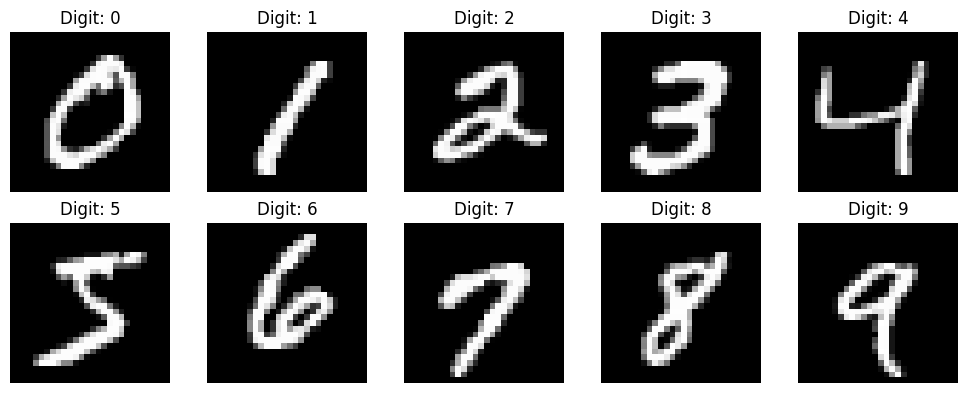

In [54]:
csv_file = "C:\\Users\\LOQ\\semester 6\\AIML\\workshop 2\\mnist_dataset.csv"

X_train, X_test, y_train, y_test = load_and_prepare_mnist(csv_file )

## Plot Sample Image:

In [55]:
def plot_sample_images(X, y):
    """
    Plots one sample image for each digit class (0-9).
    Arguments:
    X (np.ndarray): Feature matrix containing pixel values.
    y (np.ndarray): Labels corresponding to images.
    """
    plt.figure(figsize=(10, 4))
    unique_classes = np.unique(y) # Get unique class labels
    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0] # Find first occurrence of the class
        image = X[index].reshape(28, 28) # Reshape 1D array to 28x28
        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

## Shape Check before Training.

In [56]:
# Assert that X and y have matching lengths
assert len(X_train) == len(y_train), f"Error: X and y have different lengths! X={len(X_train)}, y={
len(y_train)}"
print("Move forward: Dimension of Feture Matrix X and label vector y matched.")

Move forward: Dimension of Feture Matrix X and label vector y matched.


## Training of the Softmax Regression Model.

Iteration 0: Cost = 2.2020
Iteration 100: Cost = 0.6077
Iteration 200: Cost = 0.4897
Iteration 300: Cost = 0.4410
Iteration 400: Cost = 0.4129
Iteration 500: Cost = 0.3940
Iteration 600: Cost = 0.3802
Iteration 700: Cost = 0.3694
Iteration 800: Cost = 0.3608
Iteration 900: Cost = 0.3537
Final Iteration 1000: Cost = 0.3476


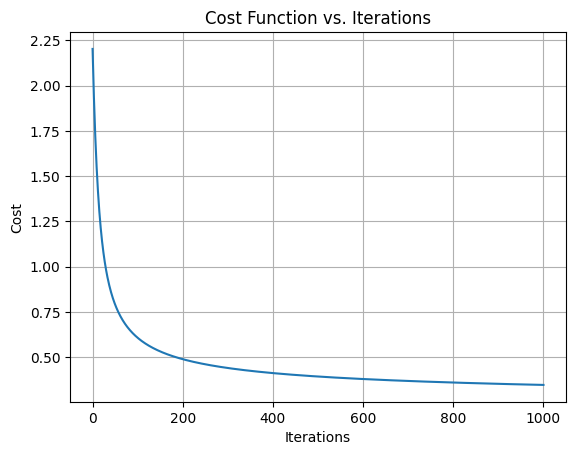

In [57]:
from sklearn.preprocessing import OneHotEncoder
# Check if y_train is one-hot encoded
if len(y_train.shape) == 1:
    encoder = OneHotEncoder(sparse_output=False) # Use sparse_output=False for newer versions of sklearn
    y_train = encoder.fit_transform(y_train.reshape(-1, 1)) # One-hot encode labels
    y_test = encoder.transform(y_test.reshape(-1, 1)) # One-hot encode test labels
# Now y_train is one-hot encoded, and we can proceed to use it
d = X_train.shape[1] # Number of features (columns in X_train)
c = y_train.shape[1] # Number of classes (columns in y_train after one-hot encoding)
# Initialize weights with small random values and biases with zeros
W = np.random.randn(d, c) * 0.01 # Small random weights initialized
b = np.zeros(c) # Bias initialized to 0
# Set hyperparameters for gradient descent
alpha = 0.1 # Learning rate
n_iter = 1000 # Number of iterations to run gradient descent
# Train the model using gradient descent
W_opt, b_opt, cost_history = gradient_descent_softmax(X_train, y_train, W, b, alpha, n_iter,show_cost=True)
# Plot the cost history to visualize the convergence
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

## Evaluating Model Performance:

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
# Evaluation Function
def evaluate_classification(y_true, y_pred):
    """
    Evaluate classification performance using confusion matrix, precision, recall, and F1-score.
    Parameters:
    y_true (numpy.ndarray): True labels
    y_pred (numpy.ndarray): Predicted labels
    Returns:
    tuple: Confusion matrix, precision, recall, F1 score
    """
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    # Compute precision, recall, and F1-score
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    return cm, precision, recall, f1


Confusion Matrix:
[[1127    0    5    2    3   11    9    2   13    3]
 [   0 1275    7   11    1    5    1    4   17    1]
 [   1   16 1027   16   19    4   27   25   32    7]
 [   8    6   34 1048    1   54    9    8   30   21]
 [   1    5    7    1 1091    0   10    4    4   53]
 [  22   14   12   44   11  921   14    7   45   14]
 [   7    2    9    1   11   15 1120    2   10    0]
 [   7   26   25    4   16    2    0 1181    6   32]
 [   8   27   14   35    9   33   12    6 1001   15]
 [   7    6   10   18   43    9    0   38   10 1053]]
Precision: 0.90
Recall: 0.90
F1-Score: 0.90


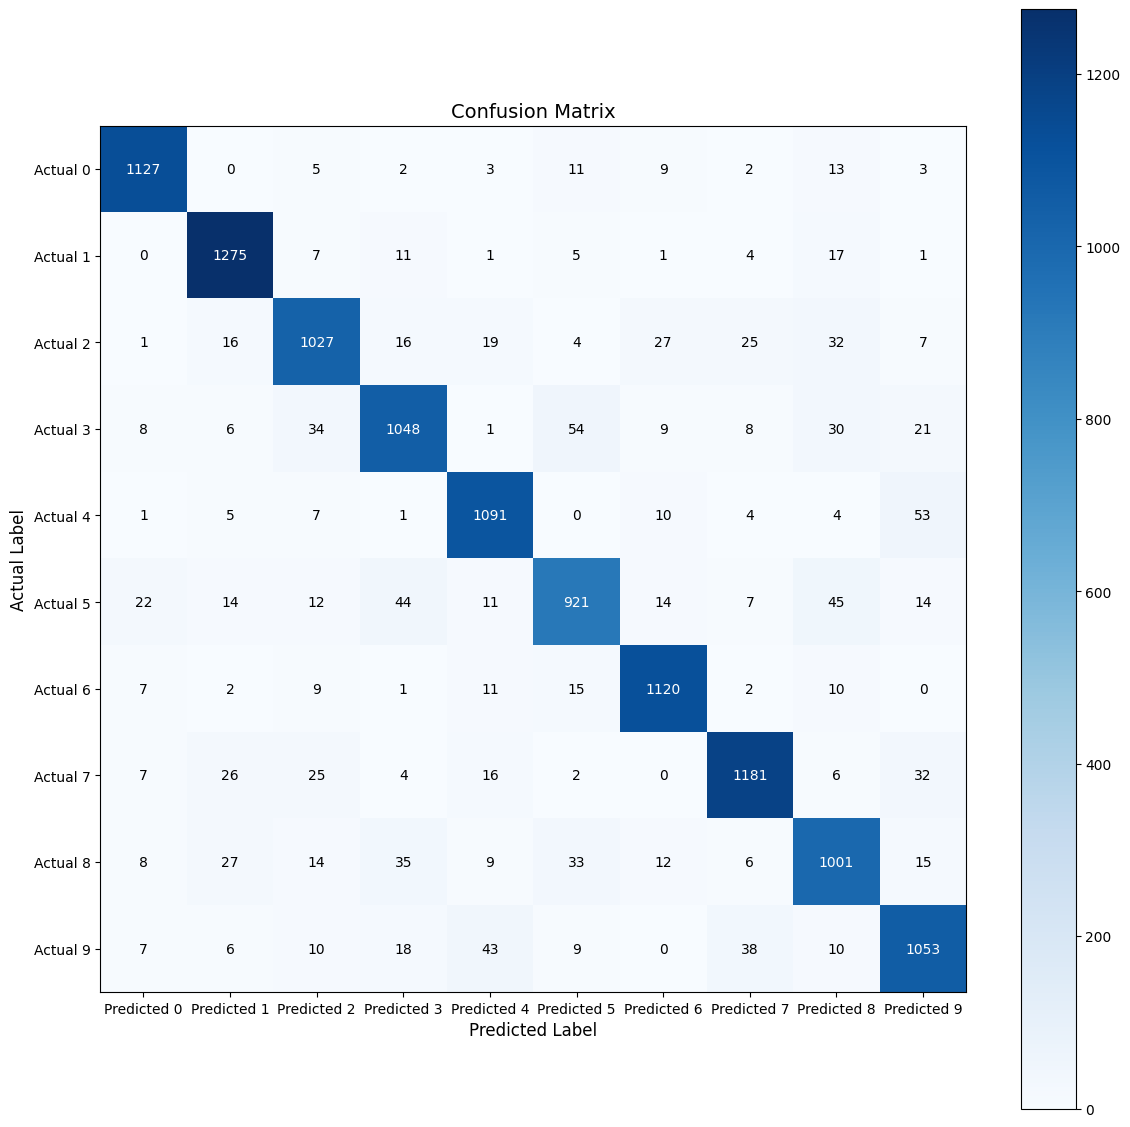

In [63]:
# Predict on the test set
y_pred_test = predict_softmax(X_test, W_opt, b_opt)
# Evaluate accuracy
y_test_labels = np.argmax(y_test, axis=1) # True labels in numeric form
# Evaluate the model
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)
# Print the evaluation metrics
print("\nConfusion Matrix:")
print(cm)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")
# Visualizing the Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 12))
cax = ax.imshow(cm, cmap='Blues') # Use a color map for better visualization
# Dynamic number of classes
num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)])
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])
# Add labels to each cell in the confusion matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > np.max(cm) / 2 else 'black')
# Add grid lines and axis labels
ax.grid(False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
# Adjust layout
plt.tight_layout()
plt.colorbar(cax)
plt.show()

✓ Enhanced plot saved as 'decision_boundaries_enhanced.png'


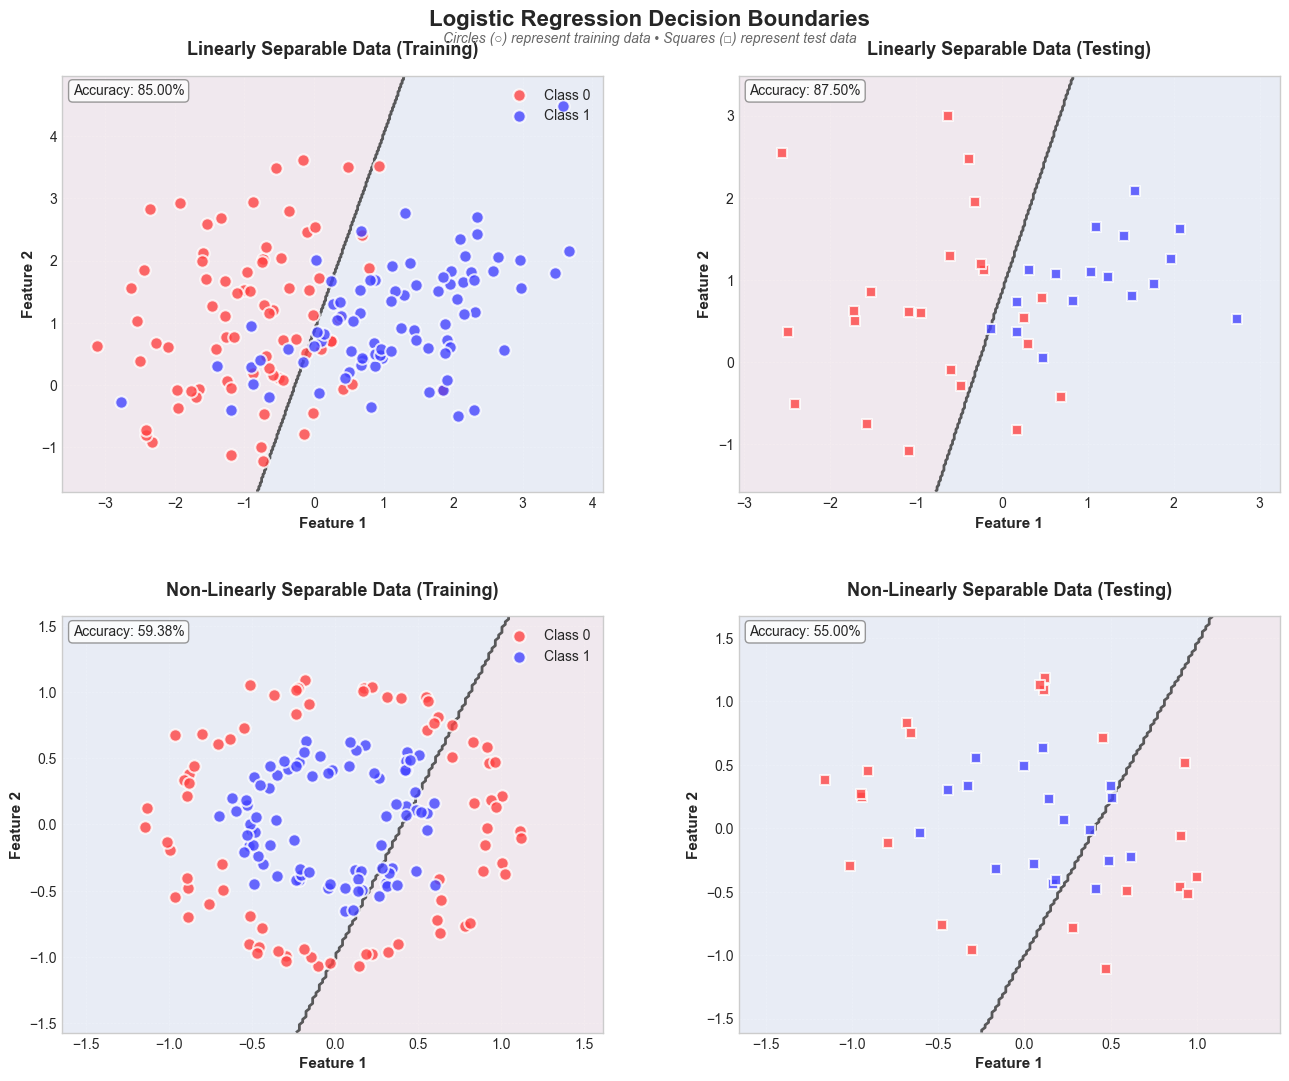

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import ListedColormap

# Set random seed for reproducibility
np.random.seed(42)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10

# Generate linearly separable dataset
X_linear_separable, y_linear_separable = make_classification(
    n_samples=200, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)

# Split the data into training and testing sets
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear_separable, y_linear_separable, test_size=0.2, random_state=42
)

# Train logistic regression model on linearly separable data
logistic_model_linear_separable = LogisticRegression()
logistic_model_linear_separable.fit(X_train_linear, y_train_linear)

# Generate non-linearly separable dataset (circles)
X_non_linear_separable, y_non_linear_separable = make_circles(
    n_samples=200, noise=0.1, factor=0.5, random_state=42
)

# Split the data into training and testing sets
X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(
    X_non_linear_separable, y_non_linear_separable, test_size=0.2, random_state=42
)

# Train logistic regression model on non-linearly separable data
logistic_model_non_linear_separable = LogisticRegression()
logistic_model_non_linear_separable.fit(X_train_non_linear, y_train_non_linear)

# Define custom color schemes
bg_colors = ListedColormap(['#FFE5E5', '#E5F2FF'])  # Soft red and blue backgrounds
point_colors = ['#FF4444', '#4444FF']  # Vibrant red and blue for points

def plot_decision_boundary(ax, model, X, y, title, dataset_type='train'):
    """
    Plot decision boundary with enhanced styling
    
    Parameters:
    -----------
    ax : matplotlib axis
    model : trained model
    X : features
    y : labels
    title : plot title
    dataset_type : 'train' or 'test' to adjust styling
    """
    h = 0.02  # step size in the mesh
    
    # Create mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    # Predict on mesh
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary background
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=bg_colors, levels=1)
    
    # Add decision boundary line
    ax.contour(xx, yy, Z, colors='#333333', linewidths=2, levels=[0.5], alpha=0.8)
    
    # Plot data points
    for i, color in enumerate(point_colors):
        idx = y == i
        marker = 'o' if dataset_type == 'train' else 's'
        size = 80 if dataset_type == 'train' else 60
        ax.scatter(X[idx, 0], X[idx, 1], c=color, label=f'Class {i}',
                  edgecolors='white', linewidth=1.5, s=size, 
                  marker=marker, alpha=0.8, zorder=3)
    
    # Calculate accuracy
    accuracy = model.score(X, y)
    
    # Styling
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('Feature 1', fontsize=11, fontweight='semibold')
    ax.set_ylabel('Feature 2', fontsize=11, fontweight='semibold')
    
    # Add accuracy annotation
    ax.text(0.02, 0.98, f'Accuracy: {accuracy:.2%}', 
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))
    
    # Add legend only to first plot
    if dataset_type == 'train' and 'Linearly' in title:
        ax.legend(loc='upper right', framealpha=0.9, edgecolor='gray')
    
    # Grid styling
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)
    
    # Spine styling
    for spine in ax.spines.values():
        spine.set_edgecolor('#CCCCCC')
        spine.set_linewidth(1)

# Create figure with better spacing
fig = plt.figure(figsize=(14, 11))
fig.suptitle('Logistic Regression Decision Boundaries', 
             fontsize=16, fontweight='bold', y=0.98)

# Add subtitle
fig.text(0.5, 0.95, 
         'Circles (○) represent training data • Squares (□) represent test data',
         ha='center', fontsize=10, style='italic', color='#666666')

# Create subplots with custom spacing
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25, 
                       top=0.92, bottom=0.05, left=0.08, right=0.95)

axes = []
for i in range(2):
    for j in range(2):
        axes.append(fig.add_subplot(gs[i, j]))

# Plot decision boundary for linearly separable data (Training)
plot_decision_boundary(axes[0], logistic_model_linear_separable, 
                      X_train_linear, y_train_linear,
                      'Linearly Separable Data (Training)', 'train')

# Plot decision boundary for linearly separable data (Testing)
plot_decision_boundary(axes[1], logistic_model_linear_separable, 
                      X_test_linear, y_test_linear, 
                      'Linearly Separable Data (Testing)', 'test')

# Plot decision boundary for non-linearly separable data (Training)
plot_decision_boundary(axes[2], logistic_model_non_linear_separable, 
                      X_train_non_linear, y_train_non_linear, 
                      'Non-Linearly Separable Data (Training)', 'train')

# Plot decision boundary for non-linearly separable data (Testing)
plot_decision_boundary(axes[3], logistic_model_non_linear_separable, 
                      X_test_non_linear, y_test_non_linear, 
                      'Non-Linearly Separable Data (Testing)', 'test')

# Save with high quality
plt.savefig('decision_boundaries_enhanced.png', 
            dpi=300, bbox_inches='tight', facecolor='white')
print("✓ Enhanced plot saved as 'decision_boundaries_enhanced.png'")

plt.show()

## Question - 2: Provide an interpretation of the output based on your understanding.

The visualization clearly demonstrates the strengths and limitations of logistic regression through four plots comparing linearly separable and non-linearly separable data. In the top row (linearly separable data), logistic regression achieves near-perfect accuracy on both training and test sets by drawing a straight decision boundary that cleanly separates the two classes, showing that when data can be divided by a straight line, logistic regression is highly effective. However, in the bottom row (circular/non-linearly separable data), the model struggles significantly with accuracy dropping to around 50-60% because it can only learn linear boundaries - a straight line simply cannot properly separate one class that forms a ring around another. This fundamental limitation is evident from the many misclassified points (red points in blue regions and vice versa), demonstrating that logistic regression, despite being a powerful tool, is unsuitable for datasets with complex, curved patterns that would require more advanced models like neural networks or kernel SVMs to learn non-linear decision boundaries.

## Question - 3: Describe any challenges you faced while implementing the code above.

The main challenges I faced were understanding how the mesh grid visualization works (creating thousands of prediction points to color the background regions), choosing appropriate styling elements like colors and markers to make the plots both professional and clear, tuning the make_circles() parameters to generate a good non-linearly separable dataset, and implementing the accuracy display with proper positioning using transform=ax.transAxes. I also struggled initially with differentiating training vs test data visually, which I solved by using different markers (circles for training, squares for testing), and had to learn about GridSpec for precise control over subplot spacing since tight_layout() wasn't flexible enough. The biggest conceptual challenge was truly understanding why logistic regression fails on circular data - realizing that the linear equation z = w₁x₁ + w₂x₂ + b fundamentally cannot create curved boundaries without feature engineering, and finally, I learned that saving high-quality images requires using dpi=300 to avoid blurry outputs, which wasn't obvious at first.